In [2]:
# The path can also be read from a config file, etc.
OPENSLIDE_PATH = r"C:\Users\wenjun\Downloads\openslide-bin-4.0.0.3-windows-x64\bin"

import os
if hasattr(os, 'add_dll_directory'):
    # Windows
    with os.add_dll_directory(OPENSLIDE_PATH):
        import openslide
else:
    import openslide

In [3]:
import numpy as np

In [4]:
slides=r"D:\datasets\PNN\TMA1054\TMA1054 hWTA.ome.tiff"

In [5]:
from openslide import OpenSlide

In [6]:
ROI_ROW_OFFSET = 15
TARGET_SLIDES={
    1: "TMA1054_HuWTA",
    2: "TMA1054_HuWTA_2"
}
CHANNEL_MULTIPLIER = 10

In [7]:
# parser.add_argument('-i', '--inputcsv', default='/datasets/PNN_study/TMA1054/TMA1054 hWTA_20230817T1508_LabWorksheet.csv', help='Path to CSV file with ROI information')
# parser.add_argument('-o', '--outputpath', default='test_images', help='Output directory path')
# parser.add_argument('-d', '--datadir', default='/datasets/PNN_study/TMA1054/', help='Data root dir')

# parser.add_argument('--tiff', type=int, default=2, help='TIFF number')
# parser.add_argument('--roi', type=int, default=50, help='ROI number')
# parser.add_argument('--test-case', action="store_true", default=False, 
#                         help='Run a small test case for algorithm inspection.')

inputcsv = r"D:\datasets\PNN\TMA1054\TMA1054 hWTA_20230817T1508_LabWorksheet.csv"
DATA_DIR=r"D:\datasets\PNN\TMA1054"
OUTPUT_DIR=r"D:\datasets\PNN\TMA1054\output"
ROI_INDEX=3

# python testpt2.py \
# -i "${INPUT_CSV}" \
# -o "${OUTPUT_DIR}" \
# -d "${DATA_DIR}" \
# --roi ${ROI_INDEX} \
# --test-case


In [8]:
from openslide import OpenSlide
from pathlib import Path
from PIL import Image, ImageEnhance, ImageDraw, ImageOps, ImageCms
from io import BytesIO
import argparse
import csv
import math
import os
import re
import matplotlib.pyplot as plt

In [9]:
def get_roi_info(csv_path):
    roi_infos = {}
    #try:
    with open(csv_path, 'r', newline='') as csvfile:
        csv_reader = csv.reader(csvfile)
        for _ in range(ROI_ROW_OFFSET): # Skip rows until column labels
            next(csv_reader)
        column_labels = next(csv_reader) # Read column labels
        for row in csv_reader: # Process each row according to column labels
            if not row:  # Skip empty rows
                continue
            row_info = {label: value for label, value in zip(column_labels, row)} # Create a dictionary for the row, mapping column label to value
            # Check if it contains valid information
            pattern = r'^\d{3}$'
            roi_value = row_info["Roi"]
            if not roi_value or (roi_value and not re.match(pattern, roi_value)):
                continue
            roi_num = row_info["Roi"]
            slide_name = row_info["Slide Name"]
            slide_key = f"{slide_name}_{roi_num}"
            roi_infos[slide_key] = row_info
    return roi_infos
    # except Exception as e:
    #     print(f"Error reading CSV file: {e}")
    #     return None

In [10]:
tiff = 1
roi = 3

In [11]:
# get roi info from corresponding slide
roi_infos = get_roi_info(inputcsv)
roi_key = f"{TARGET_SLIDES[tiff]}_{roi:03}"
roi_info = roi_infos[roi_key]


In [12]:
slides

'D:\\datasets\\PNN\\TMA1054\\TMA1054 hWTA.ome.tiff'

In [13]:
# get the slide
# file_name = f"{roi_info['Scan Name']}.ome.tiff"
#file_name = slides
#slide_path = os.path.join(DATA_DIR,file_name)#f"{DATA_DIR}{roi_info['Scan Name']}.ome.tiff" # same as [SCAN NAME]
slide = OpenSlide(slides)
excludes = ["openslide.comment", "tiff.ImageDescription"]
for k in slide.properties.keys():
    #print(k)
    if len(k) > 100 or k in excludes:
        continue
    if len(slide.properties[k]) > 1000:
        print("Skip: ", k)
        continue
    print("PROPERTY", k, slide.properties[k])

PROPERTY openslide.level-count 1
PROPERTY openslide.level[0].downsample 1
PROPERTY openslide.level[0].height 49152
PROPERTY openslide.level[0].tile-height 256
PROPERTY openslide.level[0].tile-width 256
PROPERTY openslide.level[0].width 49152
PROPERTY openslide.mpp-x 0.4007052412245552
PROPERTY openslide.mpp-y 0.4013163175214704
PROPERTY openslide.vendor generic-tiff
PROPERTY tiff.ResolutionUnit centimeter
PROPERTY tiff.XResolution 24956
PROPERTY tiff.YResolution 24918


In [14]:
def extract_roi(slide_path, roi_coord_x, roi_coord_y, area):
    estimated_radius = math.sqrt(area / math.pi) * 2.48
    size = (int(estimated_radius * 2), int(estimated_radius * 2))
    top_left_corner = (int(round(roi_coord_x - estimated_radius)), int(round(roi_coord_y - estimated_radius)))
    slide = OpenSlide(slide_path)
    #debug
    read_region_first = slide.read_region(location=top_left_corner, level=0, size=size)
    read_region_first.save("read_region_first.png")
    
    # extract the image and make it circular
    mask = Image.new("L", size, 0)
    draw = ImageDraw.Draw(mask)
    draw.ellipse((0,0)+size, fill = 255) # 255 is "on" and 0 is "off". everything that's 0 is removed from the image when we apply the mask
    roi_image = slide.read_region(location=top_left_corner, level=0, size=size)
    # debug
    roi_image.save("COLORTEST.png", icc_profile=roi_image.info.get('icc_profile'))
    pixel = roi_image.getpixel((100,100))
    print(pixel)
    print("ICC_PROFILE:", roi_image.info.get('icc_profile'))
    #
    circle_roi_image = ImageOps.fit(roi_image, mask.size, centering =(0.5,0.5)) # make sure mask is positioned correctly
    circle_roi_image.putalpha(mask)
    print("ICC_PROFILE:", circle_roi_image.info.get('icc_profile'))
    circle_roi_image.convert("RGB")
    roi_image.save("RGB.png", icc_profile=roi_image.info.get('icc_profile'))

    thumbnailimage = slide.get_thumbnail(size=size)
    thumbnailimage.save("THUMBNAIL.png")

    print("READ REGION FOR JUST A PIXEL")
    rgb_values = slide.read_region(location = top_left_corner, level= 0, size=size).convert('RGB').getpixel((0, 0))
    print(rgb_values)
    slide.close()

    region_srgb = roi_image.convert("RGB")
    region_srgb.save("COLORING.png")

    ##### check color after extraction
    print("after extraction pixel rgb information for every pixel:")
    for x in range(620):
        for y in range(620):
            r, g, b, a = circle_roi_image.getpixel((x,y))
            #print(r, g, b, a)
    rgba_values = list(circle_roi_image.getdata())
    sum_r, sum_g, sum_b, sum_a = 0, 0, 0, 0
    for pixel in rgba_values:
        sum_r += pixel[0]
        sum_g += pixel[1]
        sum_b += pixel[2]
        sum_a += pixel[3]
    print("Sum of R channel:", sum_r)
    print("Sum of G channel:", sum_g)
    print("Sum of B channel:", sum_b)
    print("Sum of A channel:", sum_a)
    #####
    return circle_roi_image

In [15]:
#circle_roi_image = extract_roi(
#         slide_path=slide_path,
#         roi_coord_x=float(roi_info['ROI Coordinate Y']),  # x and y are switched
#         roi_coord_y=float(roi_info['ROI Coordinate X']),   # x and y are switched
#         area=float(roi_info['Area']))
# bright_roi_image = adjust_brightness(circle_roi_image, 5.0)

In [16]:
area = float(roi_info['Area'])
print(area)
roi_coord_x=float(roi_info['ROI Coordinate Y'])
print(roi_coord_x)
roi_coord_y=float(roi_info['ROI Coordinate X'])
print(roi_coord_y)

49154.59
11217.60938
8119.526855


In [17]:
estimated_radius = math.sqrt(area / math.pi) * 2.48
print(estimated_radius)
size = (int(estimated_radius * 2), int(estimated_radius * 2))
print(size)
top_left_corner = (int(round(roi_coord_x - estimated_radius)), int(round(roi_coord_y - estimated_radius)))
print(top_left_corner)

310.2121355441971
(620, 620)
(10907, 7809)


In [18]:
slides

'D:\\datasets\\PNN\\TMA1054\\TMA1054 hWTA.ome.tiff'

In [19]:
slide = OpenSlide(slides)
read_region_first = slide.read_region(location=top_left_corner, level=0, size=size)
#read_region_first.save("read_region_first.png")

In [20]:
mask = Image.new("L", size, 0)
draw = ImageDraw.Draw(mask)
draw.ellipse((0,0)+size, fill = 255)

In [21]:
roi_image = slide.read_region(location=top_left_corner, level=0, size=size)

In [22]:
roi_image_arr = np.array(roi_image)

In [30]:
roi_image_arr[:,:,3]

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

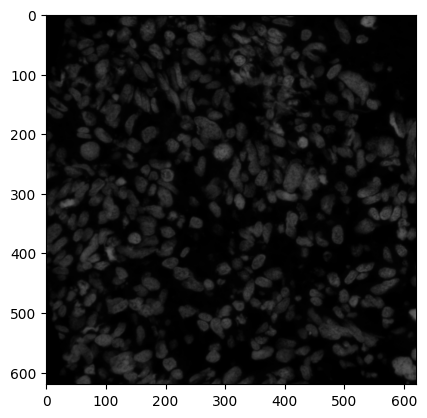

In [25]:
plt.imshow(roi_image_arr)

In [30]:
(roi_image_arr[:, :, 2] == roi_image_arr[:,:,1]).sum()

384400

In [31]:
(roi_image_arr[:,:,3] == 255).sum()

384400

In [9]:
slides = r"D:\datasets\PNN\TMA1054\TMA1054 hWTA.ome.tiff"

In [10]:
import tifffile

# Specify the path to your OME-TIFF file

# Open the OME-TIFF file
with tifffile.TiffFile(slides) as tif:
    # Read the image data
    # `asarray()` will compile all image data into a numpy array
    # This might consume a lot of memory for large images; see notes below on handling large files
    image_data = tif.asarray()

    # Access OME metadata
    ome_metadata = tif.ome_metadata

    print("Metadata:", ome_metadata)
    print("Image data shape:", image_data.shape)


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [64]:
image_data.transpose(1,2,0).shape

(49152, 49152, 3)

In [65]:
a = image_data.transpose(1,2,0)

In [76]:
target = a[7000:9000,10907:20000,:]

In [77]:
if target.dtype == np.uint16:
    target = (target / 256).astype(np.uint8)


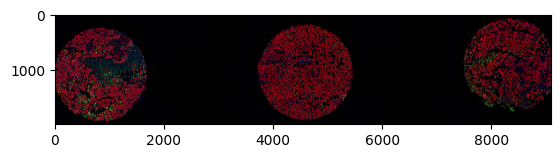

In [96]:
plt.imshow(target*10)

In [65]:
import subprocess

# Path to the QuPath executable
qupath_executable_path = r"C:\Users\wenjun\AppData\Local\QuPath-0.5.1\QuPath-0.5.1.exe"

# Command to run a QuPath script
command = [qupath_executable_path, 'script', '/path/to/script.groovy']

# Run the command
result = subprocess.run(command, capture_output=True, text=True)

# Print the output or handle errors
print("Output:", result.stdout)
print("Errors:", result.stderr)


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [9]:
from aicsimageio import AICSImage


In [10]:
img = AICSImage(slides)

In [407]:
image_data = img.get_image_data()

In [421]:
image_data.squeeze().shape

(3, 49152, 49152)

In [422]:
a = image_data.squeeze().transpose(1,2,0)

In [423]:
target = a[49152//8:49152//5,49152//8:49152//5,[2,1,0]]

In [424]:
if target.dtype == np.uint16:
    target = (target/256).astype(np.uint8)


In [425]:
target[:, :, 0] = target[:, :, 0]*0

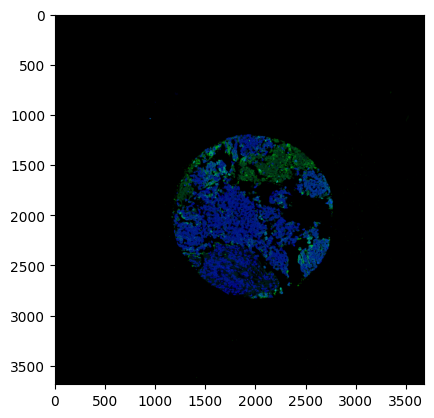

In [430]:
plt.imshow(target*25)

In [336]:
image_data = img.get_image_data("TYX", S=0, T=0, C=0)

In [345]:
max_a = image_data.max()

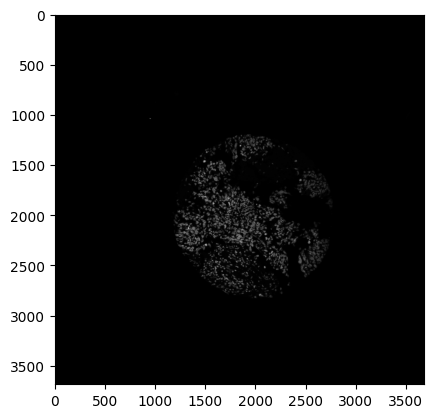

In [343]:
plt.imshow(image_data[:,49152//8:49152//5,49152//8:49152//5].transpose(1,2,0), cmap = 'gray')